<a href="https://colab.research.google.com/github/Berenger12/Berenger12/blob/main/tp_reseaux_semaine1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:

def create_friend_graph() -> dict:
    return {
        "Foli": ["Kangni", "Ekoué", "Tèko"],
        "Kangni": ["Foli", "Assiongbon", "Adama"],
        "Ekoué": ["Foli", "Ayité", "Tètè"],
        "Assiongbon": ["Kangni", "Amavi"],
        "Tèko": ["Foli", "Ayayi", "Tèvi"],
        "Adama": ["Kangni", "Dédé", "Akokoè"],
        "Ayité": ["Ekoué", "Ayélé"],
        "Amavi": ["Assiongbon", "Ayoko"],
        "Ayayi": ["Tèko", "Kayi"],
        "Tètè": ["Ekoué", "Adaku"],
        "Tèvi": ["Tèko", "Chocho"],
        "Dédé": ["Adama", "Povi"],
        "Akokoè": ["Adama", "Amélé"],
        "Ayélé": ["Ayité", "Anoko"],
        "Ayoko": ["Amavi", "Kayi"],
        "Kayi": ["Ayoko", "Ayayi"],
        "Adaku": ["Tètè", "Anoko"],
        "Chocho": ["Tèvi", "Amélé"],
        "Povi": ["Dédé", "Foli"],
        "Amélé": ["Chocho", "Akokoè"],
        "Anoko": ["Ayélé", "Adaku"]
    }

In [ ]:
def print_neighbors(graph: dict) -> None:
    """Afficher les voisins de chaque nœud dans le graphe."""
    for node, neighbors in graph.items():
        print(f"{node} est ami avec : {', '.join(neighbors)}")

In [ ]:
def build_networkx_graph(edges: list[tuple[str, str]]) -> nx.Graph:
    """Construit un graphe non orienté à partir d'une liste d'arêtes."""
    G = nx.Graph()
    G.add_edges_from(edges)
    return G

In [ ]:
def draw_graph(G: nx.Graph, title: str = "") -> None:
    """Dessine un graphe simple avec des étiquettes."""
    pos = nx.spring_layout(G)  # disposition automatique
    plt.figure(figsize=(10, 7))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
            node_size=1500, font_size=10)
    plt.title(title)
    plt.axis('off')
    plt.show()  # ← TRÈS IMPORTANT

In [ ]:

def compute_node_degrees(G: nx.Graph) -> dict[str, int]:
    """Calculer et retourner le degré de chaque nœud dans le graphe."""
    return dict(G.degree())  # Retourne un dictionnaire {nœud: degré}

In [ ]:
def is_graph_directed(G: nx.Graph) -> bool:
    """Vérifier si le graphe est dirigé."""
    return G.is_directed()

In [ ]:
[
    ("Foli", "Kangni", 2),
    ("Kangni", "Ekoué", 5),
    ("Ekoué", "Assiongbon", 3)
]

[('Foli', 'Kangni', 2), ('Kangni', 'Ekoué', 5), ('Ekoué', 'Assiongbon', 3)]

In [ ]:
def build_weighted_graph(edges: list[tuple[str, str, int]]) -> nx.Graph:
    """Construire un graphe non dirigé pondéré à partir d'arêtes avec poids."""
    G = nx.Graph()
    for u, v, w in edges:
        G.add_edge(u, v, weight=w)
    return G

In [ ]:
    print("\n--- Graphe pondéré ---")
    weighted_edges = [
        ("Foli", "Kangni", 2),
        ("Kangni", "Ekoué", 4),
        ("Ekoué", "Assiongbon", 5),
        ("Assiongbon", "Tèko", 1),
        ("Tèko", "Adama", 3),
        ("Adama", "Ayité", 6)
    ]

    G_weighted = build_weighted_graph(weighted_edges)
    print("Arêtes pondérées :", G_weighted.edges(data=True))


--- Graphe pondéré ---
Arêtes pondérées : [('Foli', 'Kangni', {'weight': 2}), ('Kangni', 'Ekoué', {'weight': 4}), ('Ekoué', 'Assiongbon', {'weight': 5}), ('Assiongbon', 'Tèko', {'weight': 1}), ('Tèko', 'Adama', {'weight': 3}), ('Adama', 'Ayité', {'weight': 6})]


In [ ]:
def draw_weighted_graph(G: nx.Graph, title: str = "") -> None:
    """Dessiner un graphe pondéré avec les poids sur les arêtes."""
    pos = nx.spring_layout(G)  # placement automatique des nœuds
    plt.figure(figsize=(10, 7))

    # Dessiner les nœuds et les arêtes
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', edge_color='gray',
            node_size=1500, font_size=10)

    # Récupérer les poids des arêtes
    edge_labels = nx.get_edge_attributes(G, 'weight')

    # Dessiner les étiquettes de poids sur les arêtes
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
def export_graph_to_gephi(G: nx.Graph, path: str) -> None:
    """Exporter un graphe NetworkX au format GEXF (pour Gephi)."""
    nx.write_gexf(G, path)
    print(f"Graphe exporté vers : {path}")

In [ ]:
    # Exporter le graphe pondéré vers un fichier GEXF
    export_graph_to_gephi(G_weighted, "graphe_pondere.gexf")

Graphe exporté vers : graphe_pondere.gexf


In [ ]:
def main() -> None:
    # 1. Créer un graphe simple (dictionnaire)
    graph_dict = create_friend_graph()

    # 2. Afficher les voisins
    print("=== Voisins de chaque nœud ===")
    print_neighbors(graph_dict)

    # 3. Construire la liste des arêtes
    edges = set()
    for node, neighbors in graph_dict.items():
        for neighbor in neighbors:
            if (neighbor, node) not in edges:
                edges.add((node, neighbor))
    edges = list(edges)

    # 4. Construire le graphe avec NetworkX
    G = build_networkx_graph(edges)

    # 5. Vérifier si le graphe est dirigé
    print("\nLe graphe est-il dirigé ?", is_graph_directed(G))

    # 6. Afficher les degrés
    print("\n=== Degrés des nœuds ===")
    degrees = compute_node_degrees(G)
    for node, degree in degrees.items():
        print(f"{node} : {degree}")

    # 7. Dessiner le graphe non pondéré
    draw_graph(G, title="Graphe social simple")

    # 8. Créer un graphe pondéré
    weighted_edges = [
        ("Foli", "Kangni", 2),
        ("Kangni", "Ekoué", 4),
        ("Ekoué", "Assiongbon", 5),
        ("Assiongbon", "Tèko", 1),
        ("Tèko", "Adama", 3),
        ("Adama", "Ayité", 6)
    ]
    G_weighted = build_weighted_graph(weighted_edges)

    # 9. Dessiner le graphe pondéré
    draw_weighted_graph(G_weighted, title="Graphe social pondéré")

    # 10. Exporter vers Gephi
    export_graph_to_gephi(G_weighted, "graphe_pondere.gexf")

=== Voisins de chaque nœud ===
Foli est ami avec : Kangni, Ekoué, Tèko
Kangni est ami avec : Foli, Assiongbon, Adama
Ekoué est ami avec : Foli, Ayité, Tètè
Assiongbon est ami avec : Kangni, Amavi
Tèko est ami avec : Foli, Ayayi, Tèvi
Adama est ami avec : Kangni, Dédé, Akokoè
Ayité est ami avec : Ekoué, Ayélé
Amavi est ami avec : Assiongbon, Ayoko
Ayayi est ami avec : Tèko, Kayi
Tètè est ami avec : Ekoué, Adaku
Tèvi est ami avec : Tèko, Chocho
Dédé est ami avec : Adama, Povi
Akokoè est ami avec : Adama, Amélé
Ayélé est ami avec : Ayité, Anoko
Ayoko est ami avec : Amavi, Kayi
Kayi est ami avec : Ayoko, Ayayi
Adaku est ami avec : Tètè, Anoko
Chocho est ami avec : Tèvi, Amélé
Povi est ami avec : Dédé, Foli
Amélé est ami avec : Chocho, Akokoè
Anoko est ami avec : Ayélé, Adaku

Le graphe est-il dirigé ? False

=== Degrés des nœuds ===
Foli : 4
Kangni : 3
Tèko : 3
Ayayi : 2
Povi : 2
Akokoè : 2
Amélé : 2
Adama : 3
Dédé : 2
Ekoué : 3
Ayité : 2
Adaku : 2
Anoko : 2
Tètè : 2
Kayi : 2
Amavi : 2
Ayo

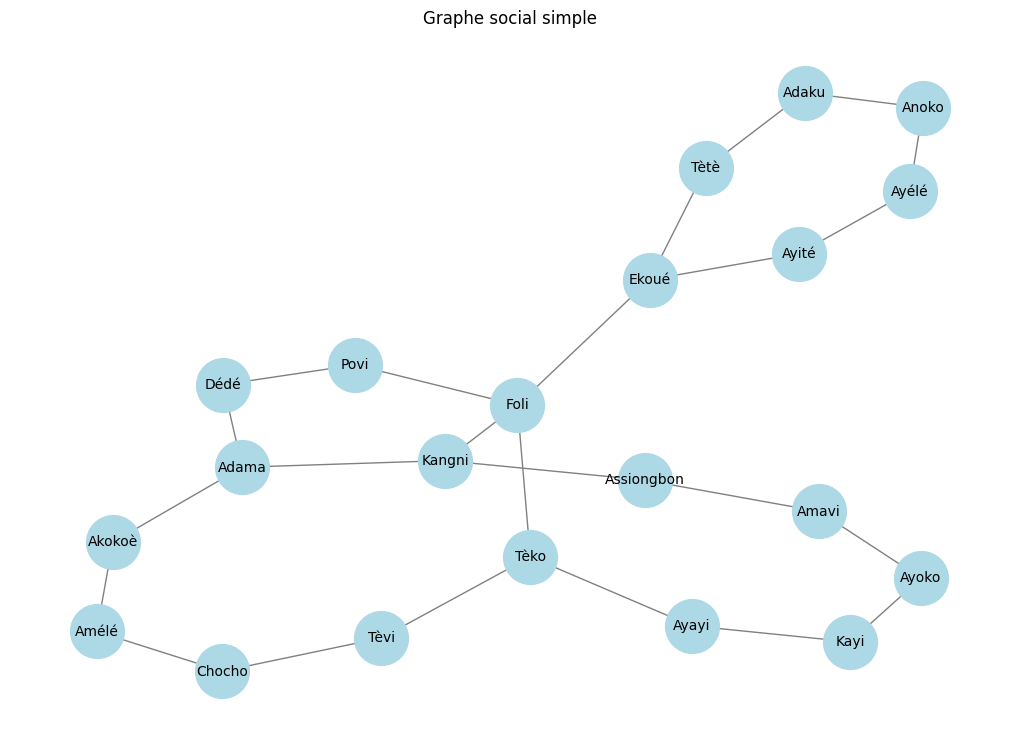

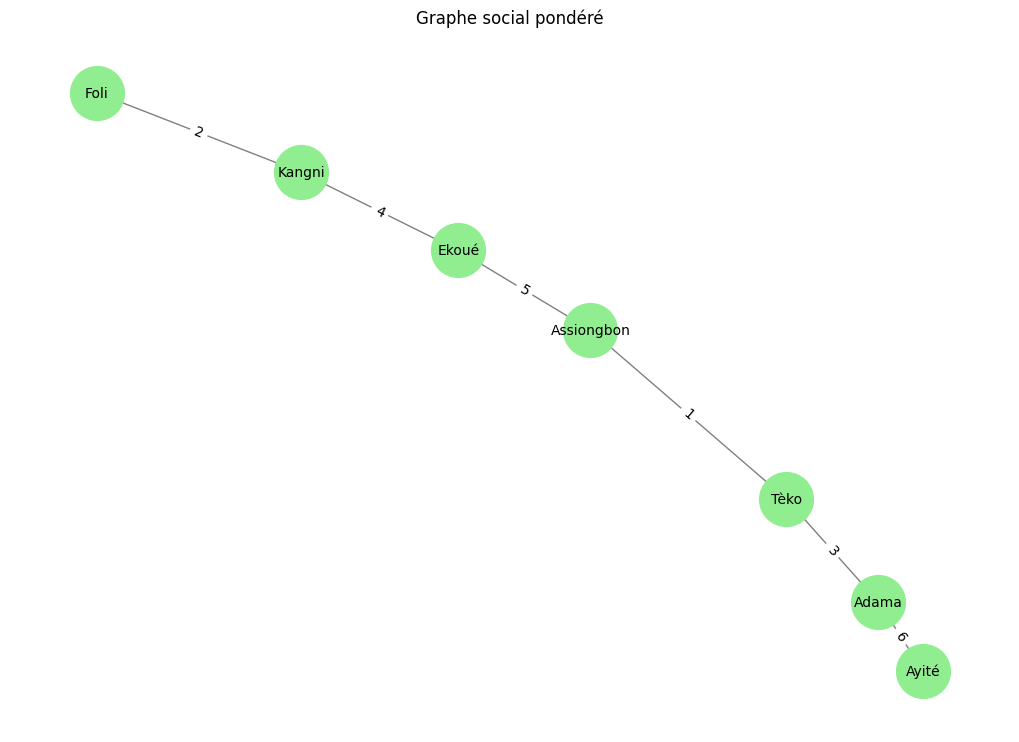

Graphe exporté vers : graphe_pondere.gexf


In [ ]:

if __name__ == "__main__":
    main()